# İlk embedding’iniz

## Egzersiz hedefleri:

- NLP için ilk RNN'nizi çalıştırın
- Gömme kavramının ne olduğunu ilk kez deneyimleyin

<hr>

Kelimeler, sinir ağına kolayca besleyebileceğiniz şeyler değildir. Bu nedenle, onları daha anlamlı bir şeye dönüştürmemiz gerekir. 

Ve _Embeddings_ kavramı tam da bunun için vardır! Herhangi bir kelimeyi vektörel bir temsil üzerine eşler (bu, her kelimeyi bir vektörle temsil etmenin süslü bir yoludur ;) ). Örneğin, `köpek` kelimesi gömme uzayında $(w_1, w_2, ..., w_n)$ vektörü ile temsil edilebilir ve biz de $(w_k)_k$ ağırlıklarını öğreniriz.

Öyleyse haydi başlayalım.

# Data

❓ **Soru** ❓ Öncelikle verileri yükleyelim. Fonksiyonda neler olduğunu anlamanıza gerek yok, burada önemi yok.

⚠️ **Uyarı** ⚠️ `load_data` fonksiyonunun bir `percentage_of_sentences` argümanı vardır. Bilgisayarınıza bağlı olarak, çok fazla cümle bilgisayarınızı yavaşlatabilir veya hatta dondurabilir - RAM'iniz taşabilir. Bu nedenle, **cümlelerin %10'uyla başlamalı** ve bilgisayarınızın bunu kaldırabildiğini görmelisiniz. Aksi takdirde, daha düşük bir sayı ile yeniden çalıştırın. 

⚠️ **DISCLAIMER** ⚠️ **_En büyüğü kimde_ (RAM) oyununu oynamaya gerek yok!** Buradaki amaç, modellerinizi hızlı bir şekilde çalıştırarak prototip oluşturmaktır. Gerçek hayatta bile, hızlı bir şekilde döngü ve hata ayıklama yapmak için verilerinizin bir alt kümesiyle başlamanız önerilir. Bu nedenle, yalnızca en iyi doğruluğu elde etmek istiyorsanız sayıyı artırın. 

In [2]:
#####################################################
### Verileri yüklemek için bu hücreyi çalıştırın  ###
#####################################################

import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.text import text_to_word_sequence

def load_data(percentage_of_sentences=None):
    train_data, test_data = tfds.load(name="imdb_reviews", split=["train", "test"], batch_size=-1, as_supervised=True)

    train_sentences, y_train = tfds.as_numpy(train_data)
    test_sentences, y_test = tfds.as_numpy(test_data)

    # Tüm verilerin yalnızca belirli bir yüzdesini alın
    if percentage_of_sentences is not None:
        assert(percentage_of_sentences> 0 and percentage_of_sentences<=100)

        len_train = int(percentage_of_sentences/100*len(train_sentences))
        train_sentences, y_train = train_sentences[:len_train], y_train[:len_train]

        len_test = int(percentage_of_sentences/100*len(test_sentences))
        test_sentences, y_test = test_sentences[:len_test], y_test[:len_test]

    X_train = [text_to_word_sequence(_.decode("utf-8")) for _ in train_sentences]
    X_test = [text_to_word_sequence(_.decode("utf-8")) for _ in test_sentences]

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_data(percentage_of_sentences=5)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/25000 [00:00<?, ? examples/s]

Shuffling /home/mert/tensorflow_datasets/imdb_reviews/plain_text/incomplete.2Y012O_1.0.0/imdb_reviews-train.tf…

...

Shuffling /home/mert/tensorflow_datasets/imdb_reviews/plain_text/incomplete.2Y012O_1.0.0/imdb_reviews-test.tfr…

Generating unsupervised examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling /home/mert/tensorflow_datasets/imdb_reviews/plain_text/incomplete.2Y012O_1.0.0/imdb_reviews-unsuperv…

Dataset imdb_reviews downloaded and prepared to /home/mert/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


2026-05-19 14:20:00.778557: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:25:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-19 14:20:00.780716: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Verileri yüklediğinize göre, şimdi bir göz atalım!

❓ **Soru** ❓ Burada verilerle oynayabilirsiniz. Özellikle, `X_train` ve `X_test` cümle listeleridir. Bunlardan bazılarını, `y_train` ve `y_test` içinde saklanan ilgili etiketleriyle birlikte yazdırın.

In [11]:
print(X_train[0])
print(y_train[0])
print(X_test[0])
print(y_test[0])

['this', 'was', 'an', 'absolutely', 'terrible', 'movie', "don't", 'be', 'lured', 'in', 'by', 'christopher', 'walken', 'or', 'michael', 'ironside', 'both', 'are', 'great', 'actors', 'but', 'this', 'must', 'simply', 'be', 'their', 'worst', 'role', 'in', 'history', 'even', 'their', 'great', 'acting', 'could', 'not', 'redeem', 'this', "movie's", 'ridiculous', 'storyline', 'this', 'movie', 'is', 'an', 'early', 'nineties', 'us', 'propaganda', 'piece', 'the', 'most', 'pathetic', 'scenes', 'were', 'those', 'when', 'the', 'columbian', 'rebels', 'were', 'making', 'their', 'cases', 'for', 'revolutions', 'maria', 'conchita', 'alonso', 'appeared', 'phony', 'and', 'her', 'pseudo', 'love', 'affair', 'with', 'walken', 'was', 'nothing', 'but', 'a', 'pathetic', 'emotional', 'plug', 'in', 'a', 'movie', 'that', 'was', 'devoid', 'of', 'any', 'real', 'meaning', 'i', 'am', 'disappointed', 'that', 'there', 'are', 'movies', 'like', 'this', 'ruining', "actor's", 'like', 'christopher', "walken's", 'good', 'name'

**ETİKETLER**: Görev bir ikili sınıflandırma problemidir:
- etiket 0️⃣ <font color=red>negatif</font> film yorumuna karşılık gelir
- etiket 1️⃣ <font color=green>pozitif</font> film yorumuna karşılık gelir

**GİRDİLER**:
- 🧹 Veri kısmen temizlenmiştir! Bu yüzden bu egzersizde bununla ilgilenmenize gerek yok.
- ❗️ Ancak gerçek hayattaki çalışmalarda bu adımı unutmamalısınız.

Kelimelerin bilgisayarlar için doğrudan uygun olmadığını hatırlıyor musunuz?  
Onları **tokenize** etmeniz gerekir!

❓ **Soru** ❓ Aşağıdaki hücreyi çalıştırarak cümlelerinizi tokenize edin

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Bu, tüm tokenizasyonu sizin için yapan bir Keras yardımcı programını başlatır.
tokenizer = Tokenizer()

# Tokenizasyon, bir tokeni (integer) her kelimeye eşleyen bir sözlüğü öğrenir.
# Bu, yalnızca eğitim setinde yapılabilir - test setini bilmemiz gerekmez!
# Bu tokenizasyon ayrıca kelimelerinizi küçük harfe çevirir, bazı filtreler uygular vb. - isterseniz dokümanı kontrol edebilirsiniz.
tokenizer.fit_on_texts(X_train)

# Tokenizasyonu eğitim ve test setine uygularız.
X_train_token = tokenizer.texts_to_sequences(X_train)
X_test_token = tokenizer.texts_to_sequences(X_test)

❓ **Soru** ❓ Beklediğiniz sonucu aldığınızdan emin olmak için tokenize edilmiş cümlelerin bazılarını yazdırın.

In [18]:
sentence_number = 100

input_raw = X_train[sentence_number]
input_token = X_train_token[sentence_number]

for i in range(40):
    print(f'Word : {input_raw[i]} -> Token {input_token[i]}')

Word : i -> Token 10
Word : enjoyed -> Token 552
Word : this -> Token 11
Word : movie -> Token 18
Word : and -> Token 3
Word : after -> Token 104
Word : watching -> Token 163
Word : it -> Token 9
Word : it -> Token 9
Word : made -> Token 94
Word : me -> Token 60
Word : wonder -> Token 612
Word : just -> Token 40
Word : how -> Token 85
Word : many -> Token 107
Word : 'caitlin -> Token 11891
Word : rose's' -> Token 11892
Word : exist -> Token 1545
Word : in -> Token 8
Word : the -> Token 1
Word : world -> Token 181
Word : how -> Token 85
Word : many -> Token 107
Word : other -> Token 80
Word : girls -> Token 455
Word : have -> Token 27
Word : been -> Token 86
Word : subjected -> Token 3774
Word : to -> Token 5
Word : this -> Token 11
Word : sort -> Token 373
Word : of -> Token 4
Word : sexual -> Token 930
Word : abuse -> Token 2547
Word : and -> Token 3
Word : torment -> Token 8132
Word : by -> Token 32
Word : classmates -> Token 5136
Word : and -> Token 3
Word : have -> Token 27


Her kelimeyi bir token ile eşleştiren sözlüğe `tokenizer.word_index` ile erişilebilir.

❓ **Soru** ❓ Eğitim setindeki farklı kelimelerin (=tokenlerin) sayısını depolayan bir `vocab_size` değişkeni ekleyin. Buna _sözcük dağarcığının boyutu_ (_size of the vocabulary_) denir.

In [21]:
vocab_size = len(tokenizer.word_index) + 1
print(vocab_size)

21411


`X_train_token` ve `X_test_token` farklı uzunluklarda diziler içerir.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/NLP/padding.png" alt='Padding example' width="700px" />

Ancak, bir sinir ağı girdi olarak bir tensör içermelidir. Bu nedenle, verilerinizi doldurmanız gerekir.

❓ **Soru** ❓  Verilerinizi `pad_sequences` işleviyle doldurun (belgeler [burada](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/sequence/pad_sequences)). `dtype` ve `padding` anahtar kelimelerini unutmayın (ancak burada `maxlen` kullanmayın).

In [23]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_padded = pad_sequences(
    X_train_token,
    dtype="int32",
    padding="post"
)

X_test_padded = pad_sequences(
    X_test_token,
    dtype="int32",
    padding="post"
)

# RNN

Şimdi bu verileri Tekrarlayan Sinir Ağına aktaralım.

❓ **Soru** ❓ Aşağıdakileri içeren bir model yazın:
- `input_dim` değeri kelime dağarcığınızın boyutu (= `vocab_size`) olan ve `output_dim` değeri istediğiniz gömme alanının boyutu olan bir gömme katmanı
- bir RNN (SimpleRNN, LSTM, GRU) katmanı
- bir Yoğun katman
- bir çıktı katmanı

⚠️ **Uyarı** ⚠️ Burada maskeleme katmanına ihtiyacınız yoktur. Neden? Çünkü `layers.Embedding` bunu doğrudan yapmak için bir argümana sahiptir ve bunu `mask_zero=True` ile ayarlamanız gerekir. Bu aynı zamanda verilerinizin **0** ile doldurulması **GEREKTİĞİ** anlamına gelir (bu varsayılan davranıştır). Bunun `input_dim`'i nasıl **etkilediğini** anlamak için [belgelere](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding#example_2) bakın.

<details>
    <summary>💡İpucu</summary>

`input_dim` kelime dağarcığının büyüklüğü + 1'e eşit olmalıdır

</details>

Uygun argümanlarla derleyin.

In [32]:
from tensorflow.keras import Sequential, Input, layers

embedding_dimension = 50

model = Sequential()

model.add(Input(shape=X_train_padded.shape[1:]))

model.add(layers.Embedding(input_dim=vocab_size + 1, output_dim=embedding_dimension, mask_zero=True))
model.add(layers.LSTM(20))
model.add(layers.Dense(10, activation="relu"))
model.add(layers.Dense(1, activation="sigmoid"))

model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

❓ **Soru** ❓ RNN'nizdeki parametre sayısına bakın. 

In [33]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 1005, 50)       │     1,070,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 20)             │         5,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,076,501 (4.11 MB)

 Trainable params: 1,076,501 (4.11 MB)

 Non-trainable params: 0 (0.00 B)

❓ Gömme katmanınızdaki parametre sayısının (kelime dağarcığınızdaki kelime sayısı + maskeleme değeri için 1) $\times$ gömme boyutunuzla eşit olduğunu iki kez kontrol edin.

In [34]:
print(f'Expected number of parameters : {(vocab_size + 1) * embedding_dimension}')

Expected number of parameters : 1070600


❓ **Soru** ❓ Modelinizi 20 dönemle ve sabır değeri 4 olan erken durdurma kriteriyle uyumlaştırmaya başlayın.

⚠️ **Uyarı** ⚠️ Bunun çok zaman aldığını görebilirsiniz! 

**Bu yüzden birkaç yinelemeden sonra durdurun!**

In [36]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(patience=4, restore_best_weights=True)

model.fit(X_train_padded, y_train,
          epochs=20,
          batch_size=16,
          validation_split=0.3,
          callbacks=[es]
         )

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 24s 374ms/step - accuracy: 0.5051 - loss: 0.6927 - val_accuracy: 0.4960 - val_loss: 0.6921
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 21s 379ms/step - accuracy: 0.5611 - loss: 0.6807 - val_accuracy: 0.5253 - val_loss: 0.6825
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 21s 374ms/step - accuracy: 0.7177 - loss: 0.6061 - val_accuracy: 0.6800 - val_loss: 0.6136
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 21s 382ms/step - accuracy: 0.8697 - loss: 0.4294 - val_accuracy: 0.7280 - val_loss: 0.5436
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 21s 387ms/step - accuracy: 0.9246 - loss: 0.2609 - val_accuracy: 0.7760 - val_loss: 0.5030
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 22s 391ms/step - accuracy: 0.9600 - loss: 0.1475 - val_accuracy: 0.7600 - val_loss: 0.5500
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 370ms/step - accuracy: 0.9840 - loss: 0.0614 - val_accuracy: 0.7787 - val_loss: 0.5954
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 369ms/step - accuracy: 0.9943 - loss: 0.0272 - val_accu

Ekrana bakarak veya kahve içerek çok fazla zaman kaybetmeyelim. Ara vermeye başlamak için henüz çok erken ;)

❓ **Soru** ❓ Hesaplama süresini kısaltacağız. Başlangıç olarak, tren setinizin farklı cümlelerinde kaç kelime olduğunu görelim (aşağıdaki hücreyi çalıştırın).

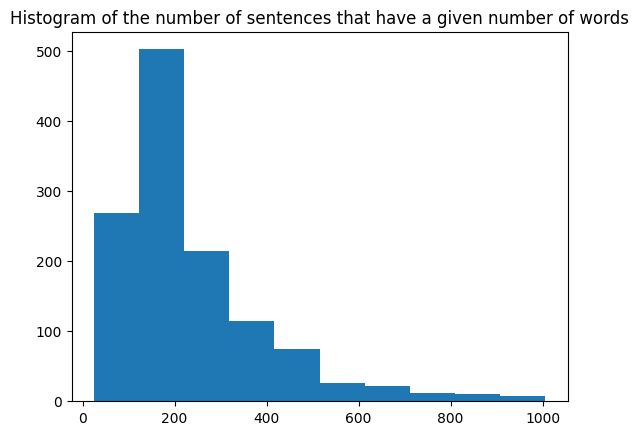

In [37]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_hist(X):
    len_ = [len(_) for _ in X]
    plt.hist(len_)
    plt.title('Histogram of the number of sentences that have a given number of words')
    plt.show()

plot_hist(X_train)


Muhtemelen cümlelerinizin %90 ila %95'inin 300 kelimeden az olduğunu göreceksiniz. Ve çok azı 1000 kelimeden fazladır.

Ancak, yukarıdaki dolguda `maxlen` kullanmadığınız için, girdi tensörünüzün boyutu, en fazla kelimeye sahip cümlenin uzunluğuna eşittir.

Şimdi, bunun dolguyu nasıl etkilediğine bakalım: 


<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/NLP/tensor_size.png" alt='Dimensions of the tensor' width="700px" />

Birkaç çok uzun cümle nedeniyle, tensörünüzün bir boyutu yaklaşık 1000'e eşittir. Ancak, ~200 kelimelik cümlelerin çoğu, işe yaramayan dolgu değerlerine sahiptir.

Dolayısıyla, tensörünüz çoğunlukla işe yaramayan bilgilerden oluşur ve bu da eğitim sürecine zaman ekler.

Peki, verileri maksimum uzunluk (`maxlen`) olarak örneğin 200 (kelime) olacak şekilde doldurursanız ne olur?
- İlk olarak, bu yakınsamayı artıracak ve algoritmanın yakınsamayı beklerken ekrana bakmanıza gerek kalmayacaktır.
- Ancak esasen, gerçekten bu kadar çok bilgiyi kaybediyor musunuz? Bir cümlenin olumlu mu olumsuz mu olduğunu anlamak için genellikle 200 kelimeden (1000'e kadar) fazlasına ihtiyaç duyduğunuzu düşünüyor musunuz?

❓ **Soru** ❓ Tüm bu nedenlerden dolayı, `maxlen` anahtar kelimesini kullanarak dolguyu yeniden yapın ve modeli yeniden eğitin!  Performansı düşürmeden, şimdi ne kadar hızlı olduğunu görün ;)

In [38]:
X_train_pad = pad_sequences(X_train_token, dtype='float32', padding='post', maxlen=200)
X_test_pad = pad_sequences(X_test_token, dtype='float32', padding='post', maxlen=200)

model.fit(X_train_pad, y_train,
          epochs=20,
          batch_size=16,
          validation_split=0.3,
          callbacks=[es]
         )

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.9554 - loss: 0.1429 - val_accuracy: 0.7893 - val_loss: 0.5470
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.9817 - loss: 0.0642 - val_accuracy: 0.7493 - val_loss: 0.6396
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.9931 - loss: 0.0322 - val_accuracy: 0.7947 - val_loss: 0.6333
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.9977 - loss: 0.0170 - val_accuracy: 0.7840 - val_loss: 0.7897


🏁 Harika, artık `Tokenizer` ve `pad_sequences` kullanabilirsiniz.

💾 Not defterinizi git add/commit/push yapmayı unutmayın...

🚀 ... ve bir sonraki göreve geçin!